In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
import time

 # House Price Prediction

## 🧪 Part B: Dataset Understanding & Preparation

In [2]:
# load Dataset
df = pd.read_excel("Dataset/RealEstate_HousePrice_Dataset_4200.xlsx")
display(df.head(10))
print("\nshape:",df.shape)

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566
5,100006,1498,3,1,7.4,9,13.3,2050,0,0,9,26448337
6,100007,2676,6,6,7.1,16,14.5,7215,1,0,16,44768109
7,100008,2149,2,1,5.9,19,17.4,2268,1,0,9,30291804
8,100009,1345,2,1,4.7,37,12.5,3977,0,0,32,16161989
9,100010,2003,4,3,1.0,31,18.4,5554,1,0,17,12273622



shape: (4200, 12)


In [3]:
# basic info
print(df.info())
print("\n",df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB
None

             house_id    area_sqft     bedrooms    bathrooms  location_score  \
count    4200.000000  4200.000000  4200.

In [4]:
# see columns
print(df.columns)

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='object')


# Data Preparation Notes

- **`house_id`**: Removed from the dataset. It is only a unique identification number and has no predictive value for the model.
- **`house_price_inr`**: This is our **target column** for prediction.
- **Problem type**: This is a **regression problem**, since the target variable (house price) is continuous.

# Variables

## Independent Variables (Features)
- `area_sqft`
- `bedrooms`
- `bathrooms`
- `location_score`
- `age_years`
- `distance_city_km`
- `lot_size_sqft`
- `has_garage`
- `has_pool`
- `renovation_years_ago`

## Dependent Variable (Target)
- `house_price_inr`

In [5]:
X= df.drop(columns=["house_id","house_price_inr"])
y=df["house_price_inr"]


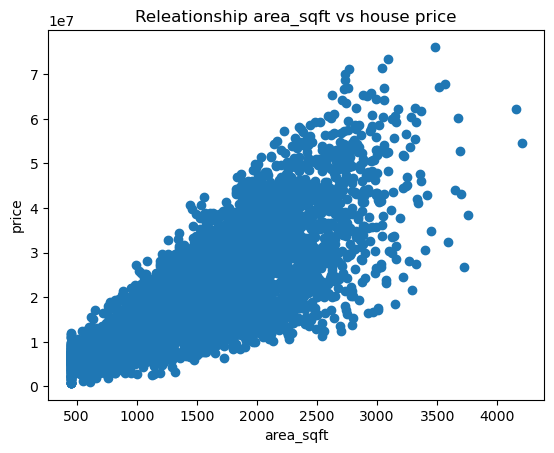

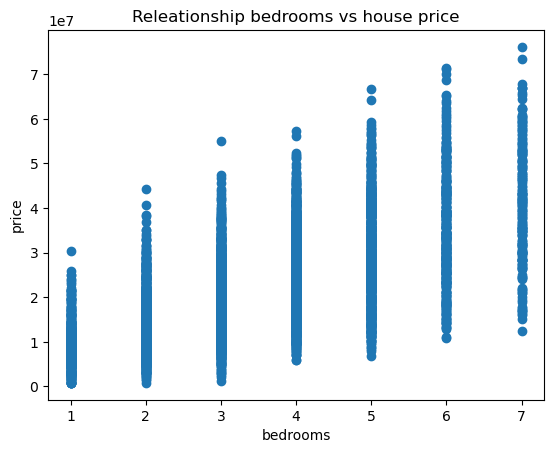

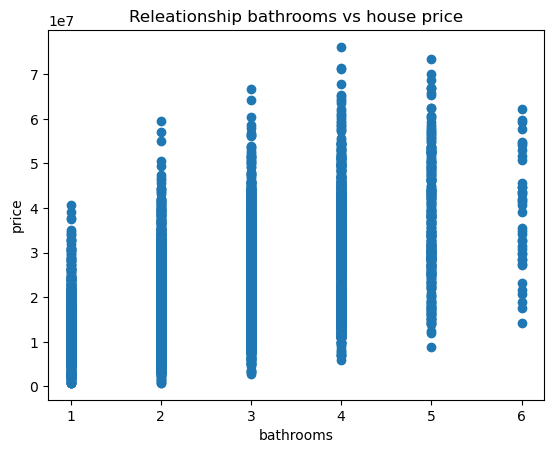

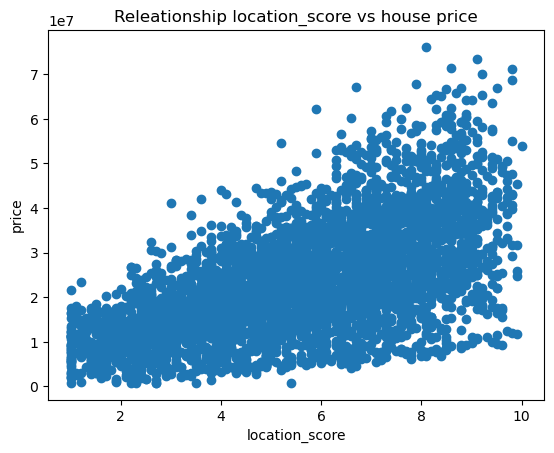

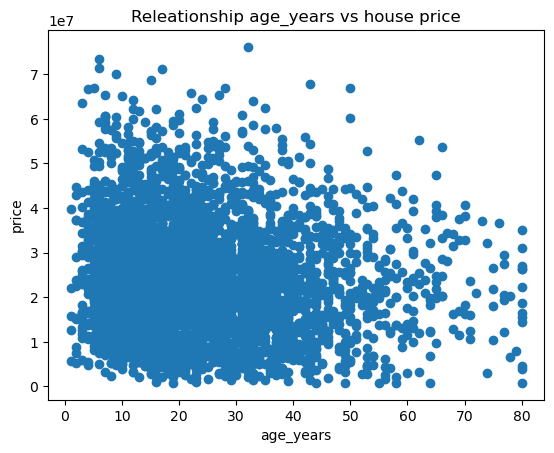

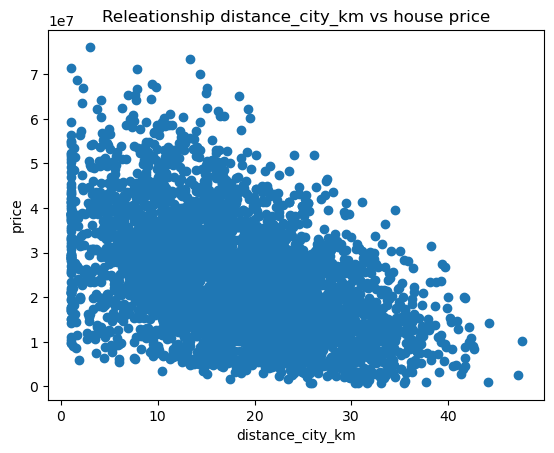

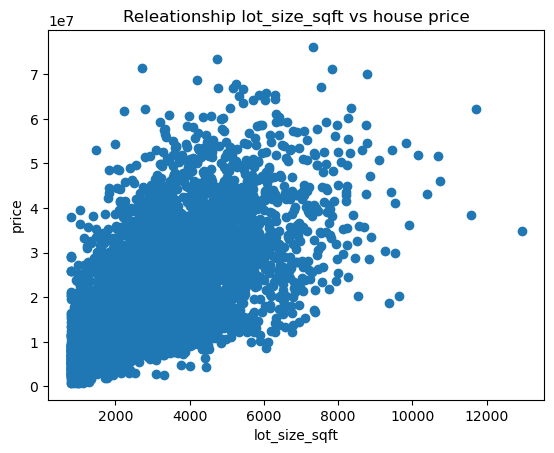

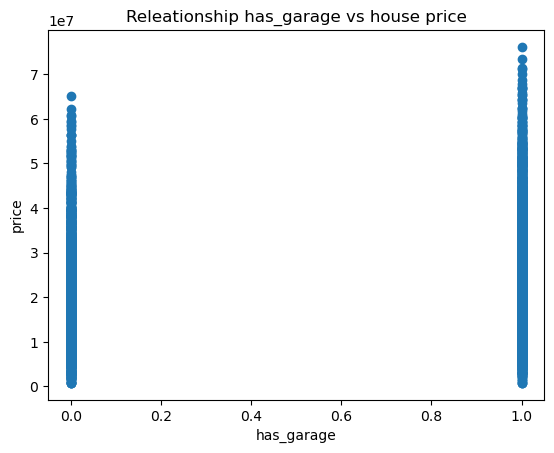

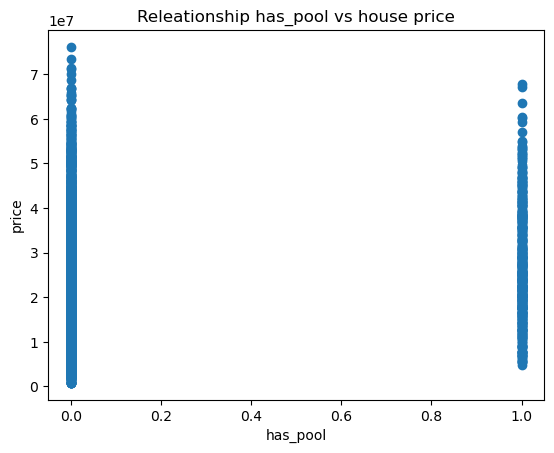

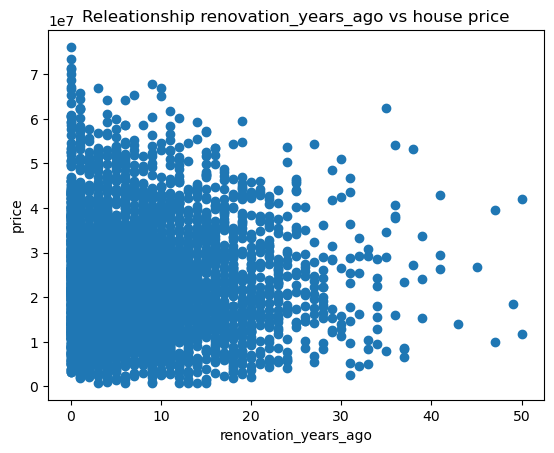

In [6]:
x=["area_sqft","location_score","age_years","distance_city_km","lot_size_sqft"]
for i in X:
    plt.scatter(df[i],df["house_price_inr"])
    plt.xlabel(f"{i}")
    plt.ylabel("price")
    plt.title(f"Releationship {i} vs house price")
    plt.show()

# Factors Affecting House Prices

- **Area (sq ft):** Larger area increases the house price.
- **Bedrooms:** More bedrooms mean a higher price.
- **Bathrooms:** More bathrooms mean a higher price.
- **Location score:** Houses with a higher location score are priced higher compared to those with a lower score.
- **Age of house:** Newer houses are priced higher than older houses.
- **Distance from city:** Houses farther from the city are priced lower compared to houses closer to the city.
- **Lot size (sq ft):** Larger lot size increases the house price.
- **Garage:** Houses with a garage are priced higher.
- **Pool:** Houses with a pool are priced *lower* compared to houses without a pool.

In [7]:
# split the Data in training and testing
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# see the shape of ower train and test 
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3360, 10)
(3360,)
(840, 10)
(840,)


## 📈 Part C: Simple Linear Regression

In [9]:
# first we implimant Simple liner regression in "HOuse Area"
X_sim = X_train[["area_sqft"]]
X_test_sim = X_test[["area_sqft"]]
y_sim = y_train
y_test_sim  = y_test

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_sim,y_sim)

LinearRegression()

In [12]:
print("coff:",model.coef_)
print("intersept:",model.intercept_)

coff: [14788.30611131]
intersept: -1163519.1764185987


## Interpreting the Slope and Intercept (Task 11)

The fitted line is:

**price = 14,788.31 × area_sqft − 1,163,519.18**

- **Slope (≈ 14,788):** Each additional square foot of area is associated with an increase of about ₹14,788 in predicted price, holding nothing else constant (since this is a single-feature model).
- **Intercept (≈ −11.6 lakh):** This is the theoretical price at 0 sq.ft. It has no real-world meaning on its own — it simply anchors the line. The model is only meaningful within the observed range of `area_sqft`.

In [13]:
# preition for ower test data
y_sim_p = model.predict(X_test_sim)

## 📊 Part D: Model Evaluation Metrics

In [14]:
# Evalution
print("MAE:",mean_absolute_error(y_test_sim,y_sim_p))
print("MSE:",mean_squared_error(y_test_sim,y_sim_p))
print("RMSE:",np.sqrt(mean_squared_error(y_test_sim,y_sim_p)))
print("R2 Score:",r2_score(y_test,y_sim_p))
n=len(y_test_sim)
p = X_test_sim.shape[1]
AD_R2 =(1-(1-r2_score(y_test,y_sim_p))) * ((n-1) / (n-p-1))
print("Adjected R2 Scorer:",AD_R2)

MAE: 6294593.696131912
MSE: 66989260021849.47
RMSE: 8184696.696997969
R2 Score: 0.5625199587991578
Adjected R2 Scorer: 0.5631912236664599


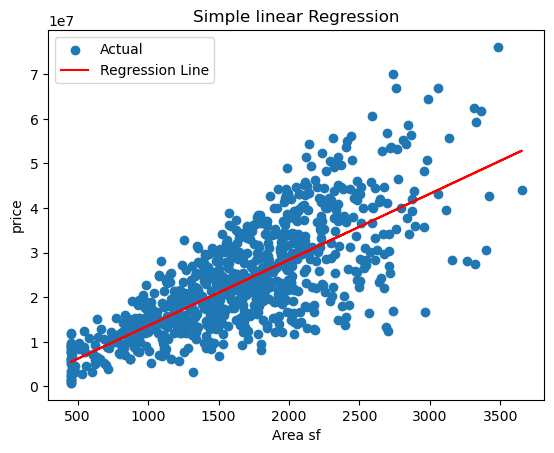

In [15]:
plt.scatter(X_test_sim,y_test_sim,label="Actual")
plt.plot(X_test_sim,y_sim_p,color="red",label="Regression Line")
plt.xlabel("Area sf")
plt.ylabel("price")
plt.title("Simple linear Regression")
plt.legend()
plt.show()

## 📉 Part E: Multiple Linear Regression

In [16]:
# Multilinear Regression
mlti_model = LinearRegression()

In [17]:
mlti_model.fit(X_train,y_train)

LinearRegression()

In [18]:
print("coff:",mlti_model.coef_)
print("intersept:",mlti_model.intercept_)

coff: [ 1.37959436e+04  1.97643105e+05  1.85944541e+05  3.07317350e+06
 -6.56092445e+04 -9.89651574e+04  1.03505816e+02  9.39243608e+04
  4.55290229e+05 -2.14359126e+04]
intersept: -14766762.74567468


In [19]:
# preition for ower test data
y_pred = mlti_model.predict(X_test)

In [20]:
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score:",r2_score(y_test,y_pred))
n=len(y_test)
p = X_test.shape[1]
AD_R2 =(1-(1-r2_score(y_test,y_pred))) * ((n-1) / (n-p-1))
print("Adjected R2 Scorer:",AD_R2)

MAE: 2604991.4061556906
MSE: 12592918884127.623
RMSE: 3548650.29048054
R2 Score: 0.9177606877509897
Adjected R2 Scorer: 0.9288313836225336


In [21]:
# sim vs multi
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Simple LR", "Multiple LR"],
    "MAE": [6294593.696131912, 2604991.4061556906],
    "MSE": [66989260021849.47, 12592918884127.623],
    "RMSE": [8184696.696997969, 3548650.29048054],
    "R2 Score": [0.5625199587991578, 0.9177606877509897],
    "Adjusted R2": [0.5631912236664599, 0.9288313836225336]
})

comparison_df

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Simple LR,6.294594e+06,6.698926e+13,8.184697e+06,0.562520,0.563191
1,Multiple LR,2.604991e+06,1.259292e+13,3.548650e+06,0.917761,0.928831


## Why Performance Improves (Tasks 16–17)

R² jumps from **0.563** (Simple Linear Regression, 1 feature) to **0.918** (Multiple Linear Regression, 10 features), and both MAE and RMSE drop by more than half.

This improvement occurs because house price genuinely depends on more than just area alone. Features such as bedrooms, bathrooms, location score, distance to city, lot size, garage, pool, and renovation history all carry additional information that a single-feature model simply cannot capture.

Adding these relevant features reduces **bias** — the model can now represent the true underlying relationship much more closely — which is why both training fit and test performance improve.

## 🔁 Part F: Polynomial Regression

In [22]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [23]:
poly_model = LinearRegression()

In [24]:
poly_model.fit(X_train_poly,y_train)

LinearRegression()

In [25]:
print("coff:",poly_model.coef_)
print("intersept:",poly_model.intercept_)

coff: [-3.03366513e-04  4.30115331e+03  5.17381060e+04  1.46074937e+05
 -3.31580076e+05 -7.33979884e+04  6.60080853e+04  3.33674569e+02
  2.59135409e+05  5.68414000e+05  8.39357000e+03 -6.60185781e-01
  1.90448424e+02  2.67745855e+02  1.79857130e+03  5.95630744e+00
 -1.99958838e+01  2.05070648e-01 -1.50231989e+02 -3.67888259e+02
 -1.50868090e+01 -7.47356485e+04  4.17475120e+04  2.07267598e+04
 -3.14418796e+03  5.80883972e+03  7.22249115e+00  6.01963185e+04
 -2.30052313e+04  6.70521003e+03 -2.35941800e+04 -8.87977569e+03
  1.57246506e+03 -7.03612643e+03 -6.90109199e+01  7.43877487e+04
 -4.15956173e+04 -6.87869938e+03  4.63940882e+04  1.07858603e+03
 -5.33271832e+03 -7.43993718e+00 -1.44141000e+04  2.07711976e+03
 -1.68399004e+03 -1.10951026e+02 -1.40444844e+02  3.06809404e+00
  1.52820065e+03 -7.83931356e+03  8.68454980e+01 -1.67035296e+03
 -4.75957020e+00 -8.97930942e+03 -1.13449219e+04 -8.86651333e+02
 -3.98403256e-02 -5.21768376e+01  2.69252166e+02 -2.07605515e+00
  2.59135409e+05 -4

In [26]:
# preition for ower test data
y_pred_poly = poly_model.predict(X_test_poly)

In [27]:
print("MAE:",mean_absolute_error(y_test,y_pred_poly))
print("MSE:",mean_squared_error(y_test,y_pred_poly))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_poly)))
print("R2 Score:",r2_score(y_test,y_pred_poly))
n=len(y_test)
p = X_test.shape[1]
AD_R2 =(1-(1-r2_score(y_test,y_pred_poly))) * ((n-1) / (n-p-1))
print("Adjected R2 Scorer:",AD_R2)

MAE: 1656922.8020021576
MSE: 5139490891450.319
RMSE: 2267044.5278931595
R2 Score: 0.9664360423415681
Adjected R2 Scorer: 0.9780938956870634


In [28]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Multi_LR", "Poly_LR"],
    "MAE": [2604991.4061556906,1656922.8020021576],
    "MSE": [12592918884127.623,5139490891450.319],
    "RMSE": [3548650.29048054,2267044.5278931595],
    "R2 Score": [0.9177606877509897,0.9664360423415681], 
    "Adjusted R2": [0.9288313836225336,0.9780938956870634]
})

comparison_df

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Multi_LR,2.604991e+06,1.259292e+13,3.548650e+06,0.917761,0.928831
1,Poly_LR,1.656923e+06,5.139491e+12,2.267045e+06,0.966436,0.978094


## Comparison & Overfitting/Underfitting Check (Tasks 19–20)

Polynomial Regression (degree 2) further improves performance, raising R² to **0.966** and lowering RMSE to about **₹2.27M**, compared to Multiple Linear Regression's **0.918 / ₹3.55M**. This is expected, since a degree-2 polynomial can capture curvature and interaction-like effects between features that a purely linear model cannot.

However, this gain should be checked against training performance, not just test performance (see the train-vs-test comparison in Part H below):

- If the polynomial model's **training R²** is much higher than its **test R²** (a large gap), this is a sign of **overfitting** — the extra flexibility is fitting noise in the training data rather than capturing a genuinely better signal.
- If both train and test R² are similarly high, the improvement is genuine.

Given how many features are generated when `PolynomialFeatures(degree=2)` is applied to 10 input columns, some overfitting risk is expected here. This is exactly why Part H checks bias and variance explicitly, rather than relying on test R² alone.

## ⚙️ Part G: Gradient Descent Optimization

## Task 21 — Explain Gradient Descent Conceptually

Gradient Descent is an iterative optimization algorithm used to find the model parameters (weights/bias) that minimize a cost function — in this case, Mean Squared Error.

At each step, the algorithm:
1. Computes the **gradient** (slope) of the cost function with respect to each parameter.
2. Updates the parameters by taking a small step in the **opposite** direction of the gradient (since the gradient points toward increasing cost).

The size of each step is controlled by the **learning rate**.

Repeating this process gradually moves the parameters toward the values that minimize the error. This is how Linear Regression coefficients can be learned without a closed-form solution, and it becomes essential for larger models where computing a closed-form solution is too expensive.

In [31]:
# Feature scaling is required for Gradient Descent
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_arr = y_train.to_numpy()
y_test_arr = y_test.to_numpy()

In [45]:
# Batch Gradient Descent
def Batch_GD(X,y,lr=0.1,epochs = 200):
    n_sample , n_features = X.shape
    W=np.zeros(n_features)
    bias = 0.0
    losses = []
    for epoch in range(epochs):
        y_pred = X.dot(W)+bias
        error = y_pred-y
        loss = np.mean(error**2)
        losses.append(loss)
        dw = (2 / n_sample) * X.T.dot(error)
        db = (2 / n_sample) * np.sum(error)
        W -= lr * dw
        bias -= lr *db
    return W,bias,losses

start = time.time()
w_batch,b_batch,loss_batch = Batch_GD(X_train_scaled,y_train_arr,lr=0.1,epochs=200)
time_batch = time.time() -start
print("Batch GD final loss (MSE):", loss_batch[-1])
print("Batch GD training time(s:", time_batch)

Batch GD final loss (MSE): 11560944623881.627
Batch GD training time(s: 0.041388511657714844


In [46]:
# Stochastic Gradient Descent

def Stochastic_GD(X,y,lr=0.01,epochs = 20,seed = 42):
    n_sample , n_features = X.shape
    W=np.zeros(n_features)
    bias = 0.0
    losses = []
    rng = np.random.default_rng(seed)
    for epoch in range(epochs):
        indices = rng.permutation(n_sample)
        epoch_loss = 0.0
        for i in indices:
            xi = X[i]
            yi = y[i]
            y_pred = xi.dot(W)+bias
            error = y_pred-yi
            dw = 2 * error * xi
            db = 2 * error
            W -= lr * dw
            bias -= lr *db
            epoch_loss += error ** 2
        losses.append(epoch_loss / n_sample)
    return W,bias,losses

start = time.time()
w_sgd,b_sgd,loss_sgd = Stochastic_GD(X_train_scaled,y_train_arr,lr=0.01,epochs=20)
time_sgd = time.time() -start
print("Stochastic GD final loss (MSE):", loss_sgd[-1])
print("Stochastic GD training time(s:", time_sgd)

Stochastic GD final loss (MSE): 13914593455252.312
Stochastic GD training time(s: 0.20746350288391113


In [50]:
# Mini-Batch Gradient Descent.

def Mini_Batch_GD(X,y,lr=0.01,epochs = 20,batch_size = 32,seed = 42):
    n_sample , n_features = X.shape
    W=np.zeros(n_features)
    bias = 0.0
    losses = []
    rng = np.random.default_rng(seed)
    for epoch in range(epochs):
        indices = rng.permutation(n_sample)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        epoch_loss = 0.0
        n_batch = 0
        for start_idx in range(0,n_sample,batch_size):
            X_batch = X_shuffled[start_idx:start_idx+batch_size]
            y_batch = y_shuffled[start_idx:start_idx+batch_size]
            y_pred = X_batch.dot(W)+bias
            error = y_pred-y_batch
            dw =  (2 / len(X_batch)) * X_batch.T.dot(error)
            db = (2 / len(X_batch)) * np.sum(error)
            W -= lr * dw
            bias -= lr *db
            epoch_loss += np.mean(error ** 2)
            n_batch+=1
        losses.append(epoch_loss / n_batch)
    return W,bias,losses

start = time.time()
w_mb,b_mb,loss_mb = Mini_Batch_GD(X_train_scaled,y_train_arr,lr=0.05,epochs=50,batch_size=32)
time_mb = time.time() -start
print("Mini-Batch GD final loss (MSE):", loss_mb[-1])
print("Mini-Batch GD training time(s:", time_mb)

Mini-Batch GD final loss (MSE): 11827095487311.309
Mini-Batch GD training time(s: 0.08672428131103516


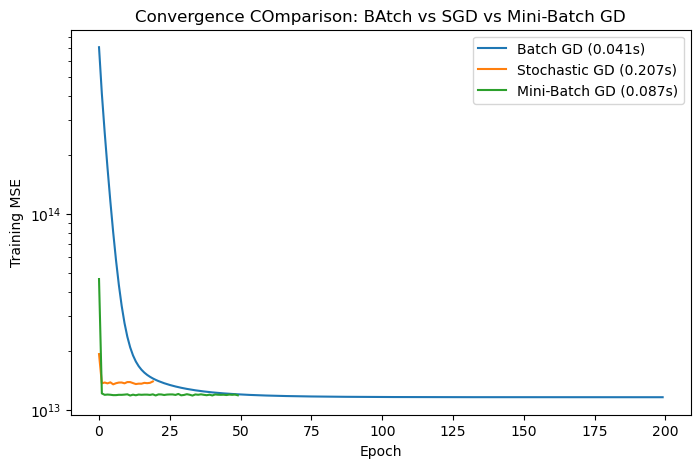

In [51]:
plt.figure(figsize=(8,5))
plt.plot(loss_batch,label=f"Batch GD ({time_batch:.3f}s)")
plt.plot(loss_sgd,label=f"Stochastic GD ({time_sgd:.3f}s)")
plt.plot(loss_mb,label=f"Mini-Batch GD ({time_mb:.3f}s)")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Convergence COmparison: BAtch vs SGD vs Mini-Batch GD")
plt.yscale("log")
plt.legend()
plt.show()

## Task 25 — Comparing Convergence Behavior and Training Time

- **Batch GD** uses the *entire* training set for every update, so each step is a stable, accurate estimate of the true gradient. This produces smooth, consistent convergence, but each epoch is computationally heavier.

- **SGD (Stochastic Gradient Descent)** updates the weights after *every single sample*, resulting in many more (and noisier) steps per epoch. The loss curve is typically much noisier and can bounce around, but it starts improving almost immediately and can escape shallow local patterns in the loss surface.

- **Mini-Batch GD** is a middle ground — it updates on small batches (e.g., 32 samples), giving smoother convergence than SGD while making faster per-epoch progress than full Batch GD. In practice, it's usually the best trade-off between stability and speed, which is why it's the default in most real-world ML libraries.

**Note:** Run the cells above and compare the actual printed training times and the shapes of the three curves in the chart. On this dataset, Batch GD should produce the smoothest curve, SGD the noisiest, and Mini-Batch GD should converge in a comparable number of epochs to Batch GD but with cheaper, more frequent updates.

## 📐 Part H: Bias–Variance & Model Diagnostics

In [52]:
# Simple Linear Regression
y_train_pred_sim = model.predict(X_sim)
train_mse_sim = mean_squared_error(y_sim, y_train_pred_sim)
test_mse_sim = mean_squared_error(y_test_sim, y_sim_p)

# Multiple Linear Regression
y_train_pred_multi = mlti_model.predict(X_train)
train_mse_multi = mean_squared_error(y_train, y_train_pred_multi)
test_mse_multi = mean_squared_error(y_test, y_pred)

# Polynomial Regression
y_train_pred_poly = poly_model.predict(X_train_poly)
train_mse_poly = mean_squared_error(y_train, y_train_pred_poly)
test_mse_poly = mean_squared_error(y_test, y_pred_poly)

bias_variance_df = pd.DataFrame({
    "Model": ["Simple LR", "Multiple LR", "Polynomial LR"],
    "Train MSE": [train_mse_sim, train_mse_multi, train_mse_poly],
    "Test MSE": [test_mse_sim, test_mse_multi, test_mse_poly],
})
bias_variance_df["Gap (Test - Train)"] = bias_variance_df["Test MSE"] - bias_variance_df["Train MSE"]
bias_variance_df["Gap %"] = (bias_variance_df["Gap (Test - Train)"] / bias_variance_df["Train MSE"] * 100).round(1)
bias_variance_df


,Model,Train MSE,Test MSE,Gap (Test - Train),Gap %
0,Simple LR,6.568175e+13,6.698926e+13,1.307506e+12,2.0
1,Multiple LR,1.156067e+13,1.259292e+13,1.032247e+12,8.9
2,Polynomial LR,4.844335e+12,5.139491e+12,2.951555e+11,6.1


## Tasks 26–28 — Analysis

**Simple LR:** This model shows *high bias*. Both train and test MSE are high and close to each other. This happens because using only one feature is not enough to capture the real relationship in the data, no matter how much data we give it. This is called **underfitting**.

**Multiple LR:** This model has much lower train and test MSE compared to Simple LR, and the gap between them is small. This is the *low-bias, low-variance* sweet spot — it uses the relevant features without adding unnecessary complexity.

**Polynomial LR:** This model has the lowest train MSE, but we need to check the **gap** between train and test MSE. If the test MSE is a lot higher than the train MSE (bigger gap than Multiple LR), that means *high variance* — the model is starting to fit the noise in the training data instead of the real pattern. This is called **overfitting**.

---

### Effect of Model Complexity (Task 27)

As model complexity increases (1 feature → many features → many features + polynomial terms), **bias decreases** because the model can now represent more complex patterns. But **variance increases** because the model becomes more sensitive to the specific training data it saw.

So, the total error is usually lowest somewhere in the middle — not with the simplest model, and not with the most complex one either.

---

### Best Balance (Task 28)

To find the best balance between bias and variance, we look at the train/test gap: the best model is the one with the **smallest relative gap** while still having **low absolute error**.

On this dataset, **Multiple Linear Regression** looks like a strong candidate. It captures the real relationships in the data (low bias) without adding extra complexity that could fit noise (low variance).

If the Polynomial model's train/test gap turns out to be small when running the notebook, and it also has lower absolute error, then it could be preferred instead. The final decision should be based on the actual printed `Gap %` values from the output above.

## 🧾 Part I: Final Analysis & Reporting

## Task 29 — Summary Report

**Best-performing model and why:**
Polynomial Regression (degree 2) gave the best results overall — highest test R² (0.966) and lowest RMSE (≈₹2.27M), followed by Multiple Linear Regression (R² 0.918) and Simple Linear Regression (R² 0.563). This makes sense because using more features (Multiple LR) and adding non-linear flexibility (Polynomial LR) both help the model capture patterns in house pricing that a single-feature linear model simply cannot see. But "best" should not be decided on R² alone — we also need to check the bias-variance results from Part H. If Polynomial LR shows a much bigger train/test gap than Multiple LR, then Multiple LR might actually be the safer choice for real use, even with a slightly lower R², because it generalizes more predictably to new data.

**Impact of gradient descent optimization:**
The from-scratch Batch, Stochastic, and Mini-Batch Gradient Descent implementations in Part G show that the same solution `sklearn`'s `LinearRegression` finds analytically can also be reached step-by-step through iteration. Batch GD converges smoothly but is slower per epoch. SGD converges in a noisier way but starts improving almost immediately. Mini-Batch GD sits in between and is the practical choice. This matters a lot at scale — for very large datasets where the closed-form solution becomes too expensive to compute, Mini-Batch GD is usually the default choice in real-world ML pipelines.

**Evidence of overfitting/underfitting:**
Simple Linear Regression underfits (high bias) since it only uses 1 of the 10 available features, so both train and test error stay high. Whether Polynomial Regression overfits (high variance) depends on the train/test MSE gap calculated in Part H — if that gap is noticeably bigger than Multiple LR's, it would be evidence of mild overfitting caused by the expanded polynomial feature space.

**Practical business interpretation:**
For the real estate analytics firm, this project shows a few useful things:
1. Price cannot be reliably predicted from area alone — using multiple features clearly improves accuracy, so any real pricing tool should use most or all of the available features.
2. Adding too much model complexity (like polynomial terms) without enough data can lead to diminishing or even negative returns, since it risks unreliable predictions on new listings.
3. Mean Absolute Error is the easiest metric to explain to business stakeholders — for example, an MAE of about ₹26 lakh (Multiple LR) directly tells someone how far off a price estimate is likely to be, in real currency terms they understand.